In [1]:
import numpy as np
import pyreadr
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
fftr = pyreadr.read_r("TEP_FaultFree_Training.RData")
ftr = pyreadr.read_r("TEP_Faulty_Training.RData")
fft = pyreadr.read_r("TEP_FaultFree_Testing.RData")
ft = pyreadr.read_r("TEP_Faulty_Testing.RData")

In [3]:
print(f"Data type of fftr is {type(fftr)},\n Data type of ftr is {type(ftr)},\n Data type of fft is {type(fft)},\n and Data type of ft is {type(ft)}")

Data type of fftr is <class 'collections.OrderedDict'>,
 Data type of ftr is <class 'collections.OrderedDict'>,
 Data type of fft is <class 'collections.OrderedDict'>,
 and Data type of ft is <class 'collections.OrderedDict'>


In [4]:
print(f"Keys of fftr is {fftr.keys()}, \n Keys of ftr is {ftr.keys()}, \n Keys of fft is {fft.keys()}, \n Keys of ft is {ft.keys()}")

Keys of fftr is odict_keys(['fault_free_training']), 
 Keys of ftr is odict_keys(['faulty_training']), 
 Keys of fft is odict_keys(['fault_free_testing']), 
 Keys of ft is odict_keys(['faulty_testing'])


In [5]:
fftr_data = fftr['fault_free_training']
ftr_data = ftr['faulty_training']
fft_data = fft['fault_free_testing']
ft_data = ft['faulty_testing']

In [6]:
data_info = pd.DataFrame({
    'fault_free_training_data' : {'rows':fftr_data.shape[0],'cols':fftr_data.shape[1]},
    'faulty_training_data' : {'rows':ftr_data.shape[0],'cols':ftr_data.shape[1]},
    'fault_free_testing_data' : {'rows':fft_data.shape[0],'cols':fft_data.shape[1]},
    'faulty_testing_data' : {'rows':ft_data.shape[0],'cols':ft_data.shape[1]}
})
data_info

,fault_free_training_data,faulty_training_data,fault_free_testing_data,faulty_testing_data
rows,250000,5000000,480000,9600000
cols,55,55,55,55


## Step 1: Analyzing Fault free data

#### a) Column data type, Missing value and features data description

In [7]:
fftr_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 55 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   faultNumber    250000 non-null  float64
 1   simulationRun  250000 non-null  float64
 2   sample         250000 non-null  int32  
 3   xmeas_1        250000 non-null  float64
 4   xmeas_2        250000 non-null  float64
 5   xmeas_3        250000 non-null  float64
 6   xmeas_4        250000 non-null  float64
 7   xmeas_5        250000 non-null  float64
 8   xmeas_6        250000 non-null  float64
 9   xmeas_7        250000 non-null  float64
 10  xmeas_8        250000 non-null  float64
 11  xmeas_9        250000 non-null  float64
 12  xmeas_10       250000 non-null  float64
 13  xmeas_11       250000 non-null  float64
 14  xmeas_12       250000 non-null  float64
 15  xmeas_13       250000 non-null  float64
 16  xmeas_14       250000 non-null  float64
 17  xmeas_15       250000 non-nul

In [8]:
fftr_data.head()

,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
0,0.0,1.0,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,...,53.744,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447
1,0.0,1.0,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,...,53.414,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194
2,0.0,1.0,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,...,54.357,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530
3,0.0,1.0,4,0.24977,3661.3,4512.1,9.4776,26.758,42.063,2707.2,...,53.946,24.725,59.856,22.277,40.257,38.072,47.541,47.658,41.643,18.089
4,0.0,1.0,5,0.29405,3679.0,4497.0,9.3381,26.889,42.650,2705.1,...,53.658,28.797,60.717,21.947,39.144,41.955,47.645,47.346,41.507,18.461


In [9]:
fftr_data.isnull().sum() #Checking missing value in each column

faultNumber      0
simulationRun    0
sample           0
xmeas_1          0
xmeas_2          0
xmeas_3          0
xmeas_4          0
xmeas_5          0
xmeas_6          0
xmeas_7          0
xmeas_8          0
xmeas_9          0
xmeas_10         0
xmeas_11         0
xmeas_12         0
xmeas_13         0
xmeas_14         0
xmeas_15         0
xmeas_16         0
xmeas_17         0
xmeas_18         0
xmeas_19         0
xmeas_20         0
xmeas_21         0
xmeas_22         0
xmeas_23         0
xmeas_24         0
xmeas_25         0
xmeas_26         0
xmeas_27         0
xmeas_28         0
xmeas_29         0
xmeas_30         0
xmeas_31         0
xmeas_32         0
xmeas_33         0
xmeas_34         0
xmeas_35         0
xmeas_36         0
xmeas_37         0
xmeas_38         0
xmeas_39         0
xmeas_40         0
xmeas_41         0
xmv_1            0
xmv_2            0
xmv_3            0
xmv_4            0
xmv_5            0
xmv_6            0
xmv_7            0
xmv_8            0
xmv_9       

In [10]:
fftr_data.describe()

,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
count,250000.0,250000.000000,250000.000000,250000.000000,250000.000000,250000.00000,250000.000000,250000.000000,250000.000000,250000.000000,...,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,0.0,250.500000,250.500000,0.250482,3663.785706,4508.81979,9.347101,26.902196,42.337598,2705.037865,...,53.973668,24.639472,61.298501,22.216644,40.055456,38.098898,46.534295,47.958591,41.104304,18.118706
std,0.0,144.337567,144.337567,0.030873,34.006357,39.21542,0.085721,0.211485,0.218513,7.525596,...,0.469663,3.037743,1.243805,0.530156,1.526751,2.965266,2.351304,2.716520,0.540817,1.463678
min,0.0,1.000000,1.000000,0.122450,3511.800000,4336.90000,8.972700,25.951000,41.394000,2672.300000,...,52.095000,11.977000,55.961000,19.749000,33.389000,25.959000,36.937000,36.641000,38.586000,11.705000
25%,0.0,125.750000,125.750000,0.229770,3640.800000,4482.40000,9.289300,26.758000,42.188000,2700.100000,...,53.657000,22.602000,60.453000,21.864000,39.021000,36.081000,44.931000,46.265000,40.740000,17.130000
50%,0.0,250.500000,250.500000,0.250510,3663.700000,4508.80000,9.347100,26.902000,42.338000,2705.000000,...,53.974000,24.644000,61.298000,22.217000,40.058000,38.091000,46.530000,47.820000,41.104000,18.119000
75%,0.0,375.250000,375.250000,0.271200,3686.800000,4535.30000,9.405100,27.046000,42.487000,2710.000000,...,54.290000,26.674000,62.144000,22.568000,41.084000,40.117000,48.140000,49.651000,41.470000,19.111000
max,0.0,500.000000,500.000000,0.391740,3808.400000,4683.70000,9.729800,27.818000,43.257000,2739.100000,...,56.118000,38.351000,66.443000,24.525000,47.498000,50.729000,56.443000,59.616000,43.930000,24.762000


### Notes:
- Values of each sensor output are of different ranges and scale. Hence Scaling will be required during preprocessing.

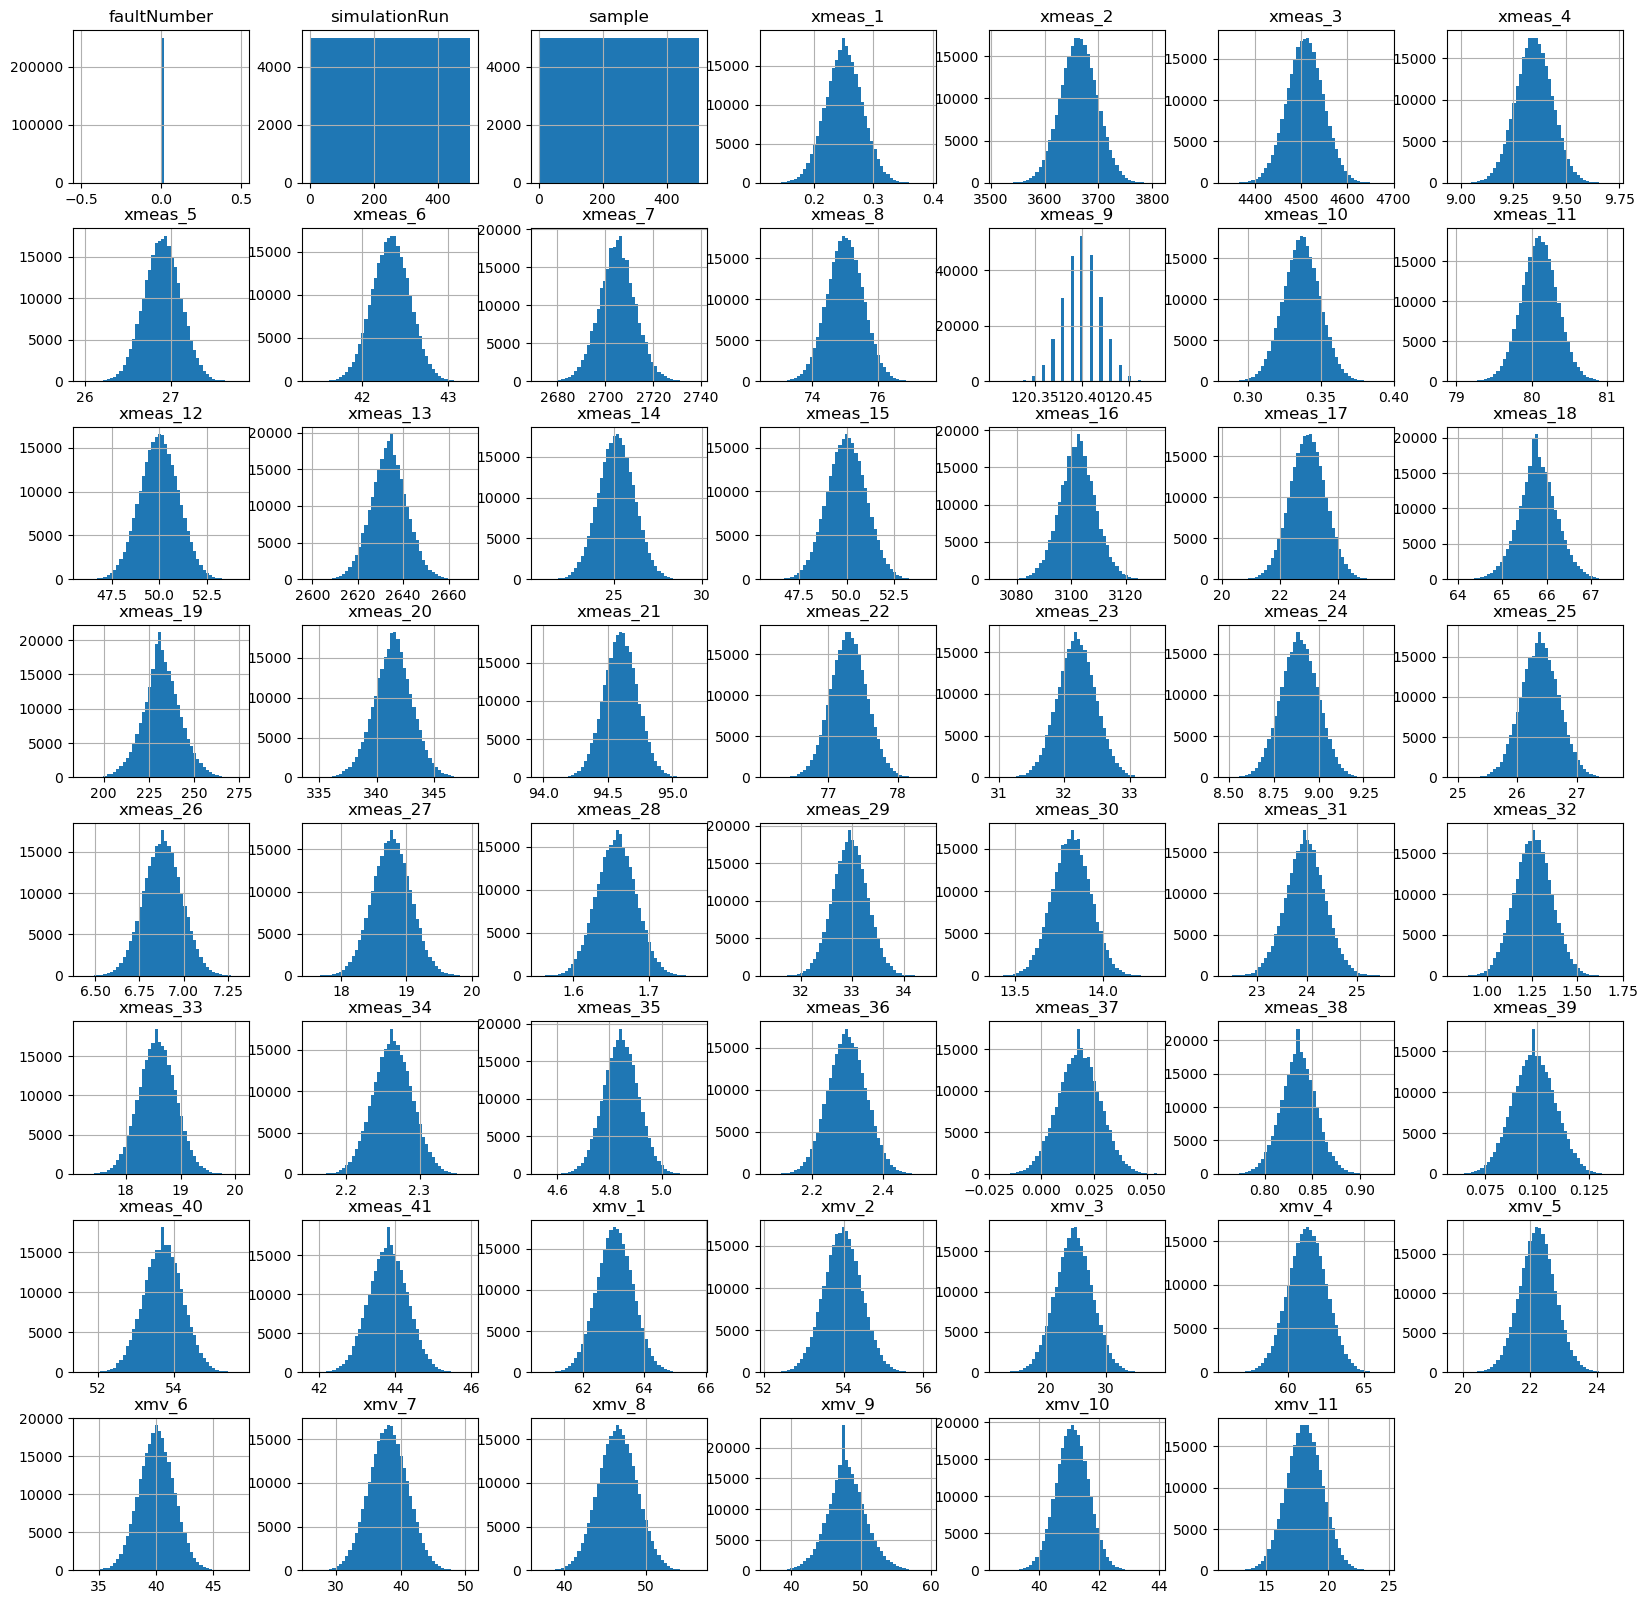

In [11]:
fftr_data.hist(bins = 50, figsize = (20,20))
plt.show()

### Observation:
- All the measured and manipulated variables in the normal operations are following the bell-curve means normally distributed about its mean.

In [12]:
fftr_data['xmeas_9'].value_counts()

xmeas_9
120.40    52465
120.41    45508
120.39    45316
120.42    30326
120.38    30077
120.43    15191
120.37    15167
120.36     5805
120.44     5777
120.35     1717
120.45     1710
120.46      398
120.34      394
120.33       68
120.47       57
120.32       12
120.48       11
120.31        1
Name: count, dtype: int64

In [13]:
## Outlier detection in each sensor data (Fault free data)
threshold = 4
window_size = 20
group_col = "simulationRun"

fftr_copy = fftr_data.copy()

for col in fftr_copy.columns:

    if col == group_col:
        continue
        
    rolling_mean = fftr_copy.groupby(group_col)[col].transform(lambda x: x.rolling(window = window_size, center = True, min_periods = 1).mean())
    rolling_std = fftr_copy.groupby(group_col)[col].transform(lambda x: x.rolling(window = window_size, center = True, min_periods = 1).std())

    rolling_std = rolling_std.replace(0, np.nan).bfill().ffill()
    z_scores = (fftr_copy[col] - rolling_mean) / rolling_std
    

    outlier_mask = np.abs(z_scores) > threshold
    

    if outlier_mask.sum() > 0:
        
        # 1. Calculate the raw difference (strength)
        difference_strength = np.abs(z_scores) - threshold

        # 2. Extract strengths ONLY for rows where it is an outlier
        outlier_strengths = difference_strength[outlier_mask]

        # 3. Find the maximum violation strength in this column
        max_violation = outlier_strengths.max()

        print(
            f"Sensor {col:10} | Outliers: {outlier_mask.sum():<5} | Max Excess Z-Score: {max_violation:.2f}"
        )
    else:
        print (f"No outlier found")

No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found


### Observation:
- Started with threshold value of 3 as -3 to 3 SD will cover 99.7% of the data points. Standard deviation is also below 1 indicating the sensors are just experiencing a tiny, normal random variations that naturally landed in the ultra-rare statistical tail of bell curve.
- Threshold of 4 gives zero outliers. However, decreasing threshold will increase the outliers as a larger window, periods of perfect calmness dilute that volatility, driving the overall rolling_std down.

In [14]:
## Outlier detection in each sensor data (Faulty data)
threshold = 4
window_size = 20
group_col = "simulationRun"

ftr_copy = ftr_data.copy()

for col in ftr_copy.columns:

    if col == group_col:
        continue
        
    rolling_mean = ftr_copy.groupby(group_col)[col].transform(lambda x: x.rolling(window = window_size, center = True, min_periods = 1).mean())
    rolling_std = ftr_copy.groupby(group_col)[col].transform(lambda x: x.rolling(window = window_size, center = True, min_periods = 1).std())

    rolling_std = rolling_std.replace(0, np.nan).bfill().ffill()
    z_scores = (ftr_copy[col] - rolling_mean) / rolling_std
    

    outlier_mask = np.abs(z_scores) > threshold
    

    if outlier_mask.sum() > 0:
        
        # 1. Calculate the raw difference (strength)
        difference_strength = np.abs(z_scores) - threshold

        # 2. Extract strengths ONLY for rows where it is an outlier
        outlier_strengths = difference_strength[outlier_mask]

        # 3. Find the maximum violation strength in this column
        max_violation = outlier_strengths.max()

        print(
            f"Sensor {col:10} | Outliers: {outlier_mask.sum():<5} | Max Excess Z-Score: {max_violation:.2f}"
        )
    else:
        print (f"No outlier found")

No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
No outlier found
Sensor xmv_9      | Outliers: 3     | Max Excess Z-Score: 0.20
No outlier found
No outlier found


### Observation:
- There are only 3 outliers in sensor xmv_9. Z-score of 0.20 shows that the value is statistically negligible as it barely exceed the threshold.

#### b) Multicollinearity check

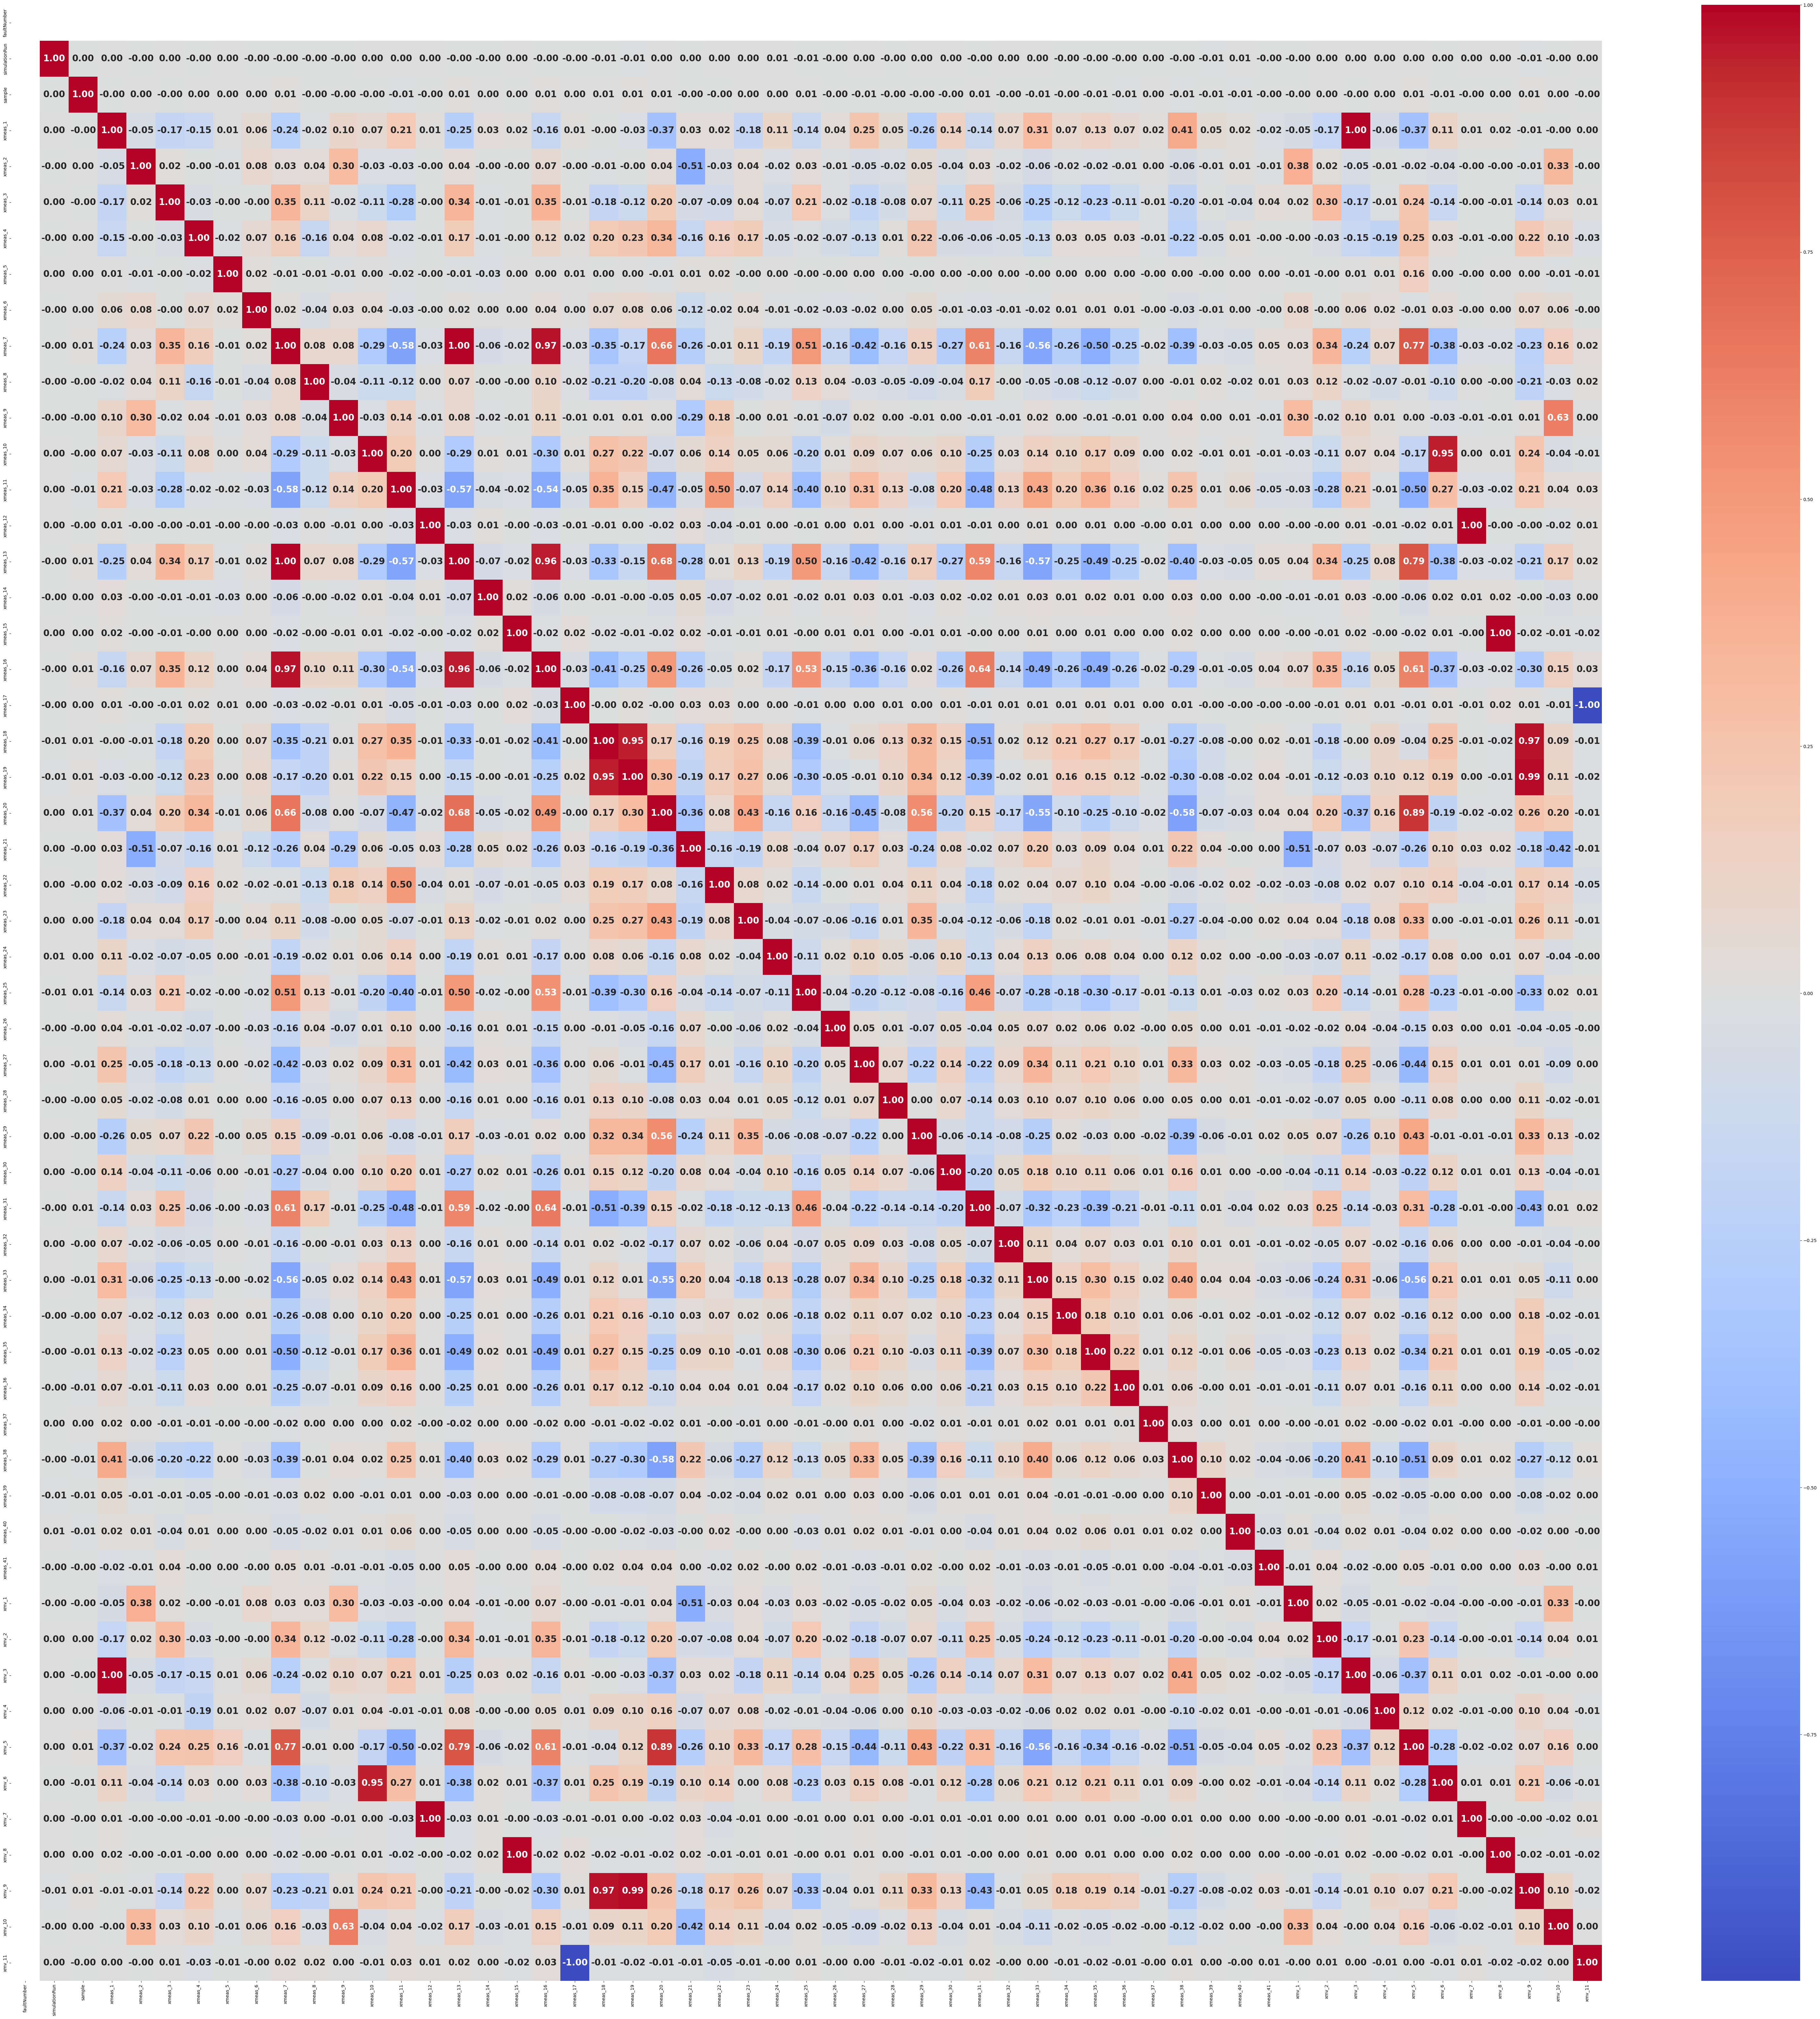

In [15]:
plt.figure(figsize = (80,80))
sns.heatmap(fftr_data.corr(), 
            annot = True, 
            cmap = 'coolwarm',
            fmt=".2f",
            annot_kws={"size": 20, "weight": "bold"})
plt.tick_params(axis='both', which='major', labelsize=10)
plt.show()

In [16]:
# Mask the upper triangle of the correlation matrix
corr_matrix = fftr_data.corr()
mask = np.tril(np.ones(corr_matrix.shape), k = -1).astype(bool)
lower_corr = corr_matrix.where(mask)

# Unstack and drop NaN values (which includes the diagonal self-correlations)
sorted_pairs = lower_corr.unstack().dropna()

strong_pairs = sorted_pairs[(sorted_pairs >= 0.7) & (sorted_pairs <= 1.0)]
print("--- Top Most Correlated Sensor Pairs in fault-free dataset ---")
print(strong_pairs)

--- Top Most Correlated Sensor Pairs in fault-free dataset ---
xmeas_1   xmv_3       0.996587
xmeas_7   xmeas_13    0.997386
          xmeas_16    0.969467
          xmv_5       0.766035
xmeas_10  xmv_6       0.948284
xmeas_12  xmv_7       1.000000
xmeas_13  xmeas_16    0.959764
          xmv_5       0.788183
xmeas_15  xmv_8       1.000000
xmeas_18  xmeas_19    0.949616
          xmv_9       0.970133
xmeas_19  xmv_9       0.986063
xmeas_20  xmv_5       0.894183
dtype: float64


### Note:
- Features having correlation more than 0.70 are listed above.

In [17]:
corr_matrix_ = ftr_data.corr().abs().unstack()
sorted_pairs_ = corr_matrix_.sort_values(ascending=False)

# Filter out self-correlation (Sensor A with Sensor A) and show the top interactions
strong_pairs_ = sorted_pairs_[(sorted_pairs_ >= 0.85) & (sorted_pairs_ < 1.0)]
print("--- Top Correlated Sensor Pairs in faulty dataset ---")
print(strong_pairs_)

--- Top Correlated Sensor Pairs in faulty dataset ---
xmv_7     xmeas_12    1.000000
xmeas_12  xmv_7       1.000000
xmeas_15  xmv_8       1.000000
xmv_8     xmeas_15    1.000000
xmeas_13  xmeas_7     0.997390
                        ...   
xmeas_31  xmeas_7     0.860555
xmeas_13  xmeas_25    0.859519
xmeas_25  xmeas_13    0.859519
xmeas_11  xmeas_31    0.859295
xmeas_31  xmeas_11    0.859295
Length: 70, dtype: float64


### Observation:
- Correlation of pair of features (>0.85) in faultfree dataset and faulty data is varying. New correlation pair of features have also emerged after fault introduction.
- Since fault-specific correlations emerge dynamically and are not known in advance, removing features based on Normal data correlation alone risks discarding sensors that become critical indicators during specific faults. Therefore, PCA should be used as it captures the full correlation structure without information loss, and changes in this structure can itself serve as a fault indicator.

In [18]:
df1 = ftr_data[(ftr_data['faultNumber'] == 1) & (ftr_data['simulationRun'] == 1)].head(20)

In [19]:
df2 = fftr_data.head(20)

In [20]:
print(df1.equals(df2)) #Comparing fault free data to faulty data

False


In [21]:
ftr_data[(ftr_data['faultNumber'] == 1) & (ftr_data['simulationRun'] == 1)].head(5)

,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
0,1,1.0,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,...,53.744,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447
1,1,1.0,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,...,53.414,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194
2,1,1.0,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,...,54.357,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530
3,1,1.0,4,0.24977,3661.3,4512.1,9.4776,26.758,42.063,2707.2,...,53.946,24.725,59.856,22.277,40.257,38.072,47.541,47.658,41.643,18.089
4,1,1.0,5,0.29405,3679.0,4497.0,9.3381,26.889,42.650,2705.1,...,53.658,28.797,60.717,21.947,39.144,41.955,47.645,47.346,41.507,18.461


In [22]:
process_cols = [col for col in fftr_data.columns if col.startswith('xmeas') or col.startswith('xmv')]

normal_stats = fftr_data[process_cols].describe()

faultfree_stats = ftr_data[
        (ftr_data['faultNumber'] == 1) &
        (ftr_data['sample'] <= 20)
][process_cols].describe()

fault1_stats = ftr_data[
        (ftr_data['faultNumber'] == 1) &
        (ftr_data['sample'] > 20)
][process_cols].describe()

comparison1 = faultfree_stats.loc['mean'] - normal_stats.loc['mean']
print("Mean deviation from normal baseline:")
print(comparison1.sort_values(ascending=False))

print("\n")

comparison2 = fault1_stats.loc['mean'] - normal_stats.loc['mean']
print("Mean deviation from normal baseline (After fault introduction):")
print(comparison2.sort_values(ascending=False))

Mean deviation from normal baseline:
xmeas_3     0.943870
xmeas_13    0.146194
xmeas_16    0.137564
xmeas_7     0.136755
xmv_8       0.030909
xmeas_15    0.013359
xmeas_20    0.009911
xmv_2       0.008384
xmeas_40    0.006400
xmeas_17    0.006098
xmeas_33    0.004738
xmv_5       0.002785
xmeas_31    0.002241
xmeas_4     0.002110
xmeas_25    0.001942
xmeas_22    0.001776
xmeas_26    0.001496
xmv_3       0.001246
xmeas_21    0.001200
xmeas_38    0.000715
xmeas_41    0.000408
xmv_7       0.000323
xmeas_39    0.000317
xmeas_37    0.000209
xmeas_23    0.000177
xmeas_32    0.000166
xmeas_12    0.000106
xmeas_9     0.000081
xmeas_28    0.000068
xmeas_1    -0.000047
xmeas_34   -0.000071
xmeas_10   -0.000316
xmeas_35   -0.000364
xmeas_24   -0.000438
xmeas_11   -0.000472
xmeas_36   -0.000563
xmeas_5    -0.000843
xmeas_27   -0.002249
xmeas_29   -0.002870
xmeas_30   -0.002882
xmeas_6    -0.004319
xmv_1      -0.006481
xmv_10     -0.007785
xmeas_8    -0.010747
xmeas_14   -0.011487
xmv_4      -0.0125

#### Observation:
- Comparison of mean of Normal dataset vs faulty dataset's mean values (first 20 rows) of each features is negligible. (Population mean invariance)
- However after fault introduction mean of Normal dataset vs faulty dataset's mean (after 20 rows) of each features shows sensor reading is deviating in some features.
- Negative deviation means sensor reading decreased from normal process mean. While positive deviation means sensor reading increased from normal process mean.

In [23]:
# Removing first 20 rows from each simulation run as fault is introduced at 21 mins
value = 1 * 60 // 3
ftr_data_clean = ftr_data[ftr_data['sample'] > value].copy()

print("Before removal:",ftr_data.shape)
print("After removal:",ftr_data_clean.shape)

Before removal: (5000000, 55)
After removal: (4800000, 55)


### Check:
##### Below code checks how consistent the fault pattern is across different simulation runs (Reproducibility (Stochasticity))

In [24]:
# Average fault mean deviation within each simulation run
process_col = ftr_data_clean.columns[3:]

for fault in sorted(ftr_data_clean['faultNumber'].unique()):
    faulty_data = ftr_data_clean[ftr_data_clean['faultNumber'] == fault]
    sim_mean = faulty_data.groupby('simulationRun')[process_col].mean()

    consistency = (sim_mean.std() / sim_mean.mean().abs()) * 100 #Coefficient of variation

    print(f"\n Fault-{fault} - Sensor consistency Across simulation")
    print(f"Most inconsistent sensors: \n{consistency.nlargest(5)}")


 Fault-1 - Sensor consistency Across simulation
Most inconsistent sensors: 
xmeas_37    5.659228
xmv_9       1.247614
xmeas_39    0.976186
xmeas_19    0.943374
xmeas_32    0.590448
dtype: float64

 Fault-2 - Sensor consistency Across simulation
Most inconsistent sensors: 
xmeas_37    5.668930
xmv_9       1.445711
xmeas_39    1.380068
xmeas_19    1.287259
xmeas_32    0.594847
dtype: float64

 Fault-3 - Sensor consistency Across simulation
Most inconsistent sensors: 
xmeas_37    5.681946
xmv_9       1.046682
xmeas_39    0.990037
xmeas_19    0.849990
xmeas_32    0.593239
dtype: float64

 Fault-4 - Sensor consistency Across simulation
Most inconsistent sensors: 
xmeas_37    5.681889
xmv_9       1.047360
xmeas_39    0.990083
xmeas_19    0.850369
xmeas_32    0.592982
dtype: float64

 Fault-5 - Sensor consistency Across simulation
Most inconsistent sensors: 
xmeas_37    5.670344
xmv_9       1.182560
xmeas_39    0.991766
xmeas_19    0.927180
xmeas_32    0.592617
dtype: float64

 Fault-6 - Sen

#### Observation:
- xmeas_37 appear in every fault. In every sensor, CV is in range of 4 to 6, indicating this is the process noise, not fault.


### Check:
#### Below code checks how far the fault pattern pushes sensors from normal (Signal strength)

In [25]:
# Average fault across all simulations 
process_col = fftr_data.columns[3:]
normal_mean = fftr_data[process_col].mean()

for fault in sorted(ftr_data_clean['faultNumber'].unique()):
    faulty_data = ftr_data_clean[ftr_data_clean['faultNumber'] == fault][process_col]

    deviation = (faulty_data.mean() - normal_mean).abs()
    top_sensors = deviation.nlargest(5)

    print(f"\nFault {fault} — Top 5 Deviated Sensors:")
    print(top_sensors)


Fault 1 — Top 5 Deviated Sensors:
xmeas_19    53.371044
xmv_3       49.953162
xmeas_3     25.173653
xmv_9       16.498391
xmeas_16     7.829817
dtype: float64

Fault 2 — Top 5 Deviated Sensors:
xmeas_3     140.468173
xmeas_19     83.502382
xmv_6        40.735404
xmeas_2      31.134267
xmv_9        19.131209
dtype: float64

Fault 3 — Top 5 Deviated Sensors:
xmv_10      0.077094
xmeas_19    0.069419
xmeas_3     0.063156
xmeas_21    0.033633
xmeas_2     0.022041
dtype: float64

Fault 4 — Top 5 Deviated Sensors:
xmv_10      3.767599
xmeas_19    0.074875
xmeas_3     0.037393
xmeas_2     0.026061
xmv_9       0.020769
dtype: float64

Fault 5 — Top 5 Deviated Sensors:
xmeas_3     9.154086
xmeas_19    4.316341
xmeas_2     3.148569
xmv_11      2.693624
xmeas_16    1.357238
dtype: float64

Fault 6 — Top 5 Deviated Sensors:
xmeas_16    296.808874
xmeas_7     252.644844
xmeas_13    244.983637
xmeas_3     219.175565
xmeas_19    194.888233
dtype: float64

Fault 7 — Top 5 Deviated Sensors:
xmv_4     

### Observation:
- xmeas_19 is the most affected sensor with the introduction of any faults within the simulation.

In [26]:
#from statsmodels.stats.outliers_influence import variance_inflation_factor

#X = fftr_data.copy() 
#X['intercept'] = 1  

#vif_data = pd.DataFrame()
#vif_data['feature'] = X.columns
#vif_data['VIF'] = [variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
#vif_data = vif_data.sort_values(by="VIF", ascending=False)

#print(len(vif_data))

In [38]:
ftr_data[(ftr_data['faultNumber'] == 1)][['simulationRun','faultNumber']]

,simulationRun,faultNumber
0,1.0,1
1,1.0,1
2,1.0,1
3,1.0,1
4,1.0,1
...,...,...
4990495,500.0,1
4990496,500.0,1
4990497,500.0,1
4990498,500.0,1
